# 最適化結果の比較: comp_ew / AI 単体 / 複合スコア（bax）

`bax/output/{score}` に置かれた最適化結果 13 本（`comp_ew`、`ens_lgbm_dnn(_hl1)`、`comp_ew_{w}_ai_{..}`、`comp_ew_{w}_ai_hl1_{..}`）を
`alphaeval.bax` で評価する。最適化条件は 13 本で同一（期間 201212〜202607、推定 TE ≤ 5%、個別 0〜10% / 対 BM ±3%、
業種 ±3%、リスクインデックス ±2sd、回転率 ≤ 15%/月、線形コスト 0.5%、ホライズン 12 か月、USD ニューメレール）。

見るもの:

1. 基本指標（グロス / コスト後 / 税後の超過、実現 TE と推定 TE、IR、回転率、集中度）
2. 累積図（対ベンチマーク、グロス / コスト後 / 税後）とアルファ横断の棒グラフ
3. 混合比率と指標（2 系統）
4. 制約の張り付き（TE 枠の消化、業種・個別の上下限、回転率上限）
5. リスクモデルによる分解（Style / Industry / Specific）
6. 制約なしの Q5 等ウェイトとの比較（最適化でどれだけアルファを実現できたか）

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, india_tax_schedule, performance_summary, portfolio_returns, quantile_analysis
from alphaeval.bax import BaxOutput, evaluate_bax, exposure_summary, factor_attribution, risk_decomposition

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

BAX_ROOT = "../../bax/output"
INPUT_ROOT = "../../input/msci_india_imi"
W = [90, 80, 70, 60, 50]
NAMES = ["comp_ew"] + [f"comp_ew_{w}_ai_{100 - w}" for w in W] + ["ens_lgbm_dnn"] + [f"comp_ew_{w}_ai_hl1_{100 - w}" for w in W] + ["ens_lgbm_dnn_hl1"]
HIGHLIGHT = ["comp_ew", "comp_ew_70_ai_30", "comp_ew_60_ai_40", "ens_lgbm_dnn"]
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
FPI_TYPE = "trust"
BURN_IN = 12
SECTOR_NAMES = {10: "エネルギー", 15: "素材", 20: "資本財", 25: "一般消費財", 30: "生活必需品", 35: "ヘルスケア", 40: "金融", 45: "情報技術", 50: "通信", 55: "公益", 60: "不動産"}

store = InputStore(INPUT_ROOT)

## 1. 一括評価

税は `risk_models/GEMLT/return` の `rtn`（INR 建て）で FIFO ロット台帳を回し、bax のコスト後リターンから税額だけを差し引く。

In [2]:
outs = {n: BaxOutput(f"{BAX_ROOT}/{n}") for n in NAMES}
first = next(iter(outs.values()))
print("最適化条件（comp_ew の bc.txt から）")
display(first.settings().set_index("item").loc[["初期 NAV", "ターゲット TE（omega）", "個別銘柄ウェイト", "個別銘柄アクティブウェイト", "アクティブ・リスクインデックス", "アクティブ・業種ウェイト", "回転率制約", "推定売買コスト", "投資ホライズン", "期間", "基軸通貨"], ["value", "interpretation"]])

rtn_inr = store.returns(RISK_MODEL, "rtn")
gics = store.alpha("attributes/gics")
schedule = india_tax_schedule(FPI_TYPE)
results = {}
for n, out in outs.items():
    sector = (gics // 1_000_000).reindex(index=out.rebalance_dates).apply(lambda c: c.map(SECTOR_NAMES))
    results[n] = evaluate_bax(out, mapping=sector, tax_schedule=schedule, tax_returns=rtn_inr, burn_in=BURN_IN)
    print(f"{n:24s} done")

最適化条件（comp_ew の bc.txt から）


,value,interpretation
item,,
初期 NAV,"100,000,000 USA",fn_init_fund の -n$2 = 100（百万単位）→ 現金 100 百万で開始
ターゲット TE（omega）,5,推定 TE ≤ 5%（年率）
個別銘柄ウェイト,"0,0.1",0% 〜 10%
個別銘柄アクティブウェイト,"-0.03,0.03",対 BM -3% 〜 3%
アクティブ・リスクインデックス,"-2,2",-2 〜 2 標準偏差
アクティブ・業種ウェイト,"-0.03,0.03",-3% 〜 3%
回転率制約,0.15,1 回のリバランスで 15% 以下（小数指定）
推定売買コスト,"1,0.5,0",線形型、固定 0.5%、変動係数 0。係数ファイル: `/home/r-yamamoto/w...
投資ホライズン,12,12 か月（取引コストの償却期間）


comp_ew                  done


comp_ew_90_ai_10         done


comp_ew_80_ai_20         done


...

comp_ew_80_ai_hl1_20     done


comp_ew_70_ai_hl1_30     done


comp_ew_60_ai_hl1_40     done


comp_ew_50_ai_hl1_50     done


ens_lgbm_dnn_hl1         done


## 2. 基本指標

In [3]:
rows = {}
for n, r in results.items():
    s = r.summary
    tt = r.tax_table
    net = performance_summary(tt["fund_after_tax"], tt["bm"])
    pos_s, pos_l = tt["gain_short"].clip(lower=0).sum(), tt["gain_long"].clip(lower=0).sum()
    rows[n] = {
        "超過 グロス": s["active_return_gross"], "超過 コスト後": s["active_return"], "超過 税後": net["active_return"],
        "TE 実現": s["tracking_error"], "TE 推定": s["omega_mean"], "実現/推定": s["te_ratio_realized_to_omega"],
        "IR コスト後": s["information_ratio"], "IR 税後": net["information_ratio"],
        "回転率": s["turnover_annual"], "コストドラッグ": s["cost_drag"], "税ドラッグ": s["active_return"] - net["active_return"], "短期比率": pos_s / (pos_s + pos_l) if pos_s + pos_l > 0 else np.nan,
        "勝率": s["hit_rate"], "最大DD 超過": s["max_drawdown_excess"], "銘柄数": s["n_hold_mean"], "アクティブシェア": s["active_share_mean"],
    }
tbl = pd.DataFrame(rows).T
display(tbl.round(3))

,超過 グロス,超過 コスト後,超過 税後,TE 実現,TE 推定,実現/推定,IR コスト後,IR 税後,回転率,コストドラッグ,税ドラッグ,短期比率,勝率,最大DD 超過,銘柄数,アクティブシェア
comp_ew,0.066,0.056,0.042,0.061,0.049,1.238,0.915,0.676,1.128,0.010,0.014,0.457,0.663,-0.108,90.055,0.663
comp_ew_90_ai_10,0.066,0.056,0.041,0.060,0.049,1.221,0.932,0.675,1.129,0.010,0.015,0.465,0.656,-0.100,88.822,0.663
comp_ew_80_ai_20,0.065,0.055,0.039,0.059,0.049,1.196,0.945,0.662,1.138,0.010,0.016,0.477,0.650,-0.093,86.902,0.662
comp_ew_70_ai_30,0.066,0.055,0.039,0.058,0.049,1.190,0.956,0.658,1.164,0.010,0.017,0.492,0.669,-0.089,84.963,0.658
comp_ew_60_ai_40,0.064,0.054,0.036,0.057,0.048,1.178,0.941,0.619,1.211,0.011,0.018,0.504,0.650,-0.094,82.736,0.653
comp_ew_50_ai_50,0.062,0.050,0.033,0.057,0.048,1.190,0.880,0.560,1.253,0.011,0.018,0.521,0.626,-0.104,81.018,0.646
ens_lgbm_dnn,0.034,0.025,0.010,0.051,0.041,1.264,0.484,0.202,1.147,0.009,0.014,0.457,0.546,-0.218,83.675,0.571
comp_ew_90_ai_hl1_10,0.064,0.055,0.040,0.060,0.049,1.219,0.916,0.660,1.100,0.010,0.015,0.459,0.632,-0.099,87.589,0.664
comp_ew_80_ai_hl1_20,0.063,0.054,0.038,0.059,0.049,1.197,0.915,0.643,1.073,0.009,0.015,0.458,0.656,-0.091,84.564,0.663
comp_ew_70_ai_hl1_30,0.061,0.052,0.037,0.058,0.049,1.189,0.902,0.628,1.043,0.009,0.015,0.446,0.656,-0.097,81.620,0.659


## 3. 累積図とアルファ横断の棒グラフ

対ベンチマークの累積超過（複利）。グロス / コスト後 / 税後。

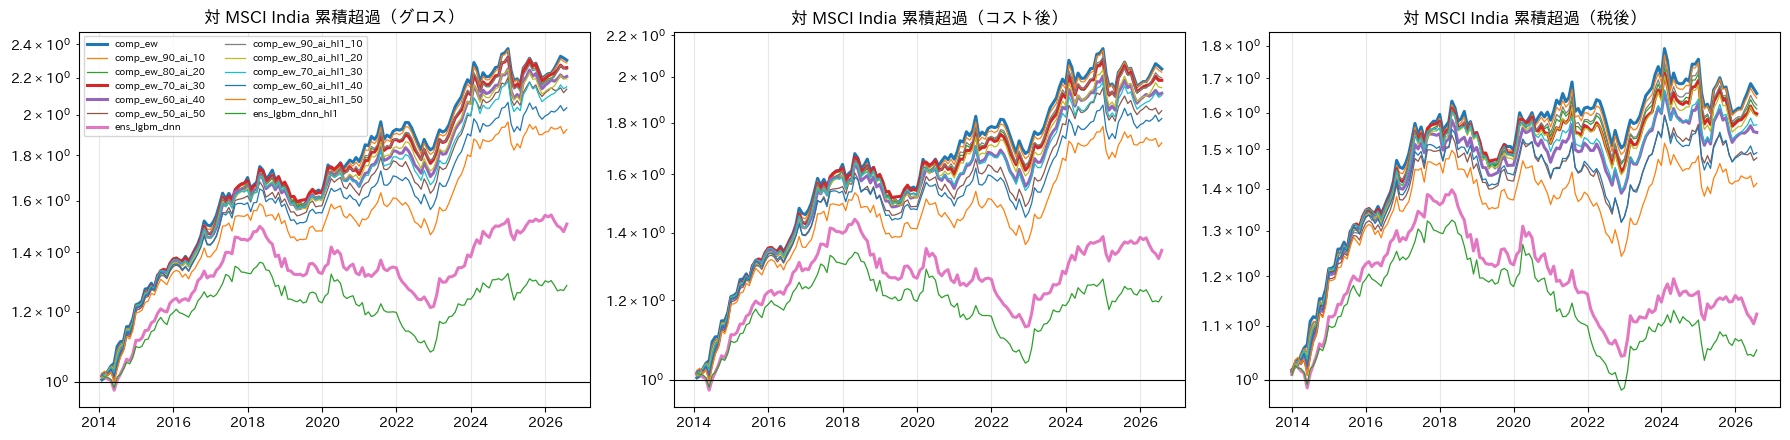

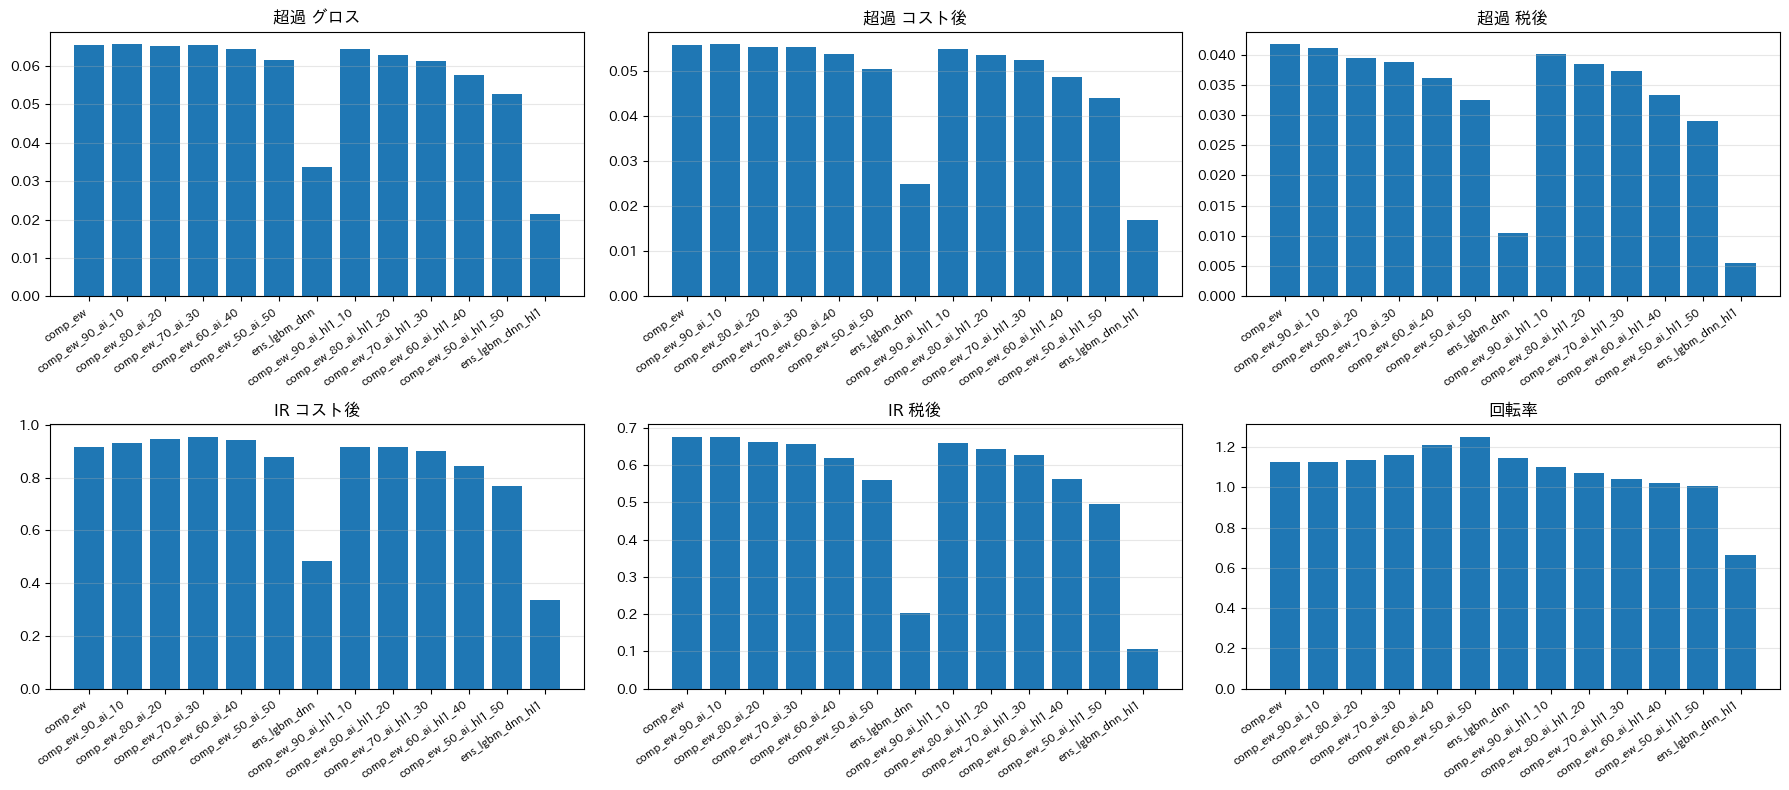

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for n, r in results.items():
    t = r.table.dropna(subset=["fund"]).iloc[BURN_IN:]
    tt = r.tax_table
    lw = 2.2 if n in HIGHLIGHT else 0.9
    axes[0].plot(t.index, (1 + t["excess_gross"]).cumprod(), label=n, linewidth=lw)
    axes[1].plot(t.index, (1 + t["excess"]).cumprod(), label=n, linewidth=lw)
    axes[2].plot(tt.index, (1 + tt["excess_after_tax"]).cumprod(), label=n, linewidth=lw)
for ax, title in zip(axes, ["超過（グロス）", "超過（コスト後）", "超過（税後）"]):
    ax.axhline(1, color="k", linewidth=0.8)
    ax.set_yscale("log")
    ax.set_title(f"対 MSCI India 累積{title}")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), ["超過 グロス", "超過 コスト後", "超過 税後", "IR コスト後", "IR 税後", "回転率"]):
    vals = tbl[col]
    ax.bar(np.arange(len(vals)), vals, color=["C0" if v >= 0 else "C3" for v in vals])
    ax.set_xticks(np.arange(len(vals)), vals.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(col)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## 4. 混合比率と指標（2 系統）

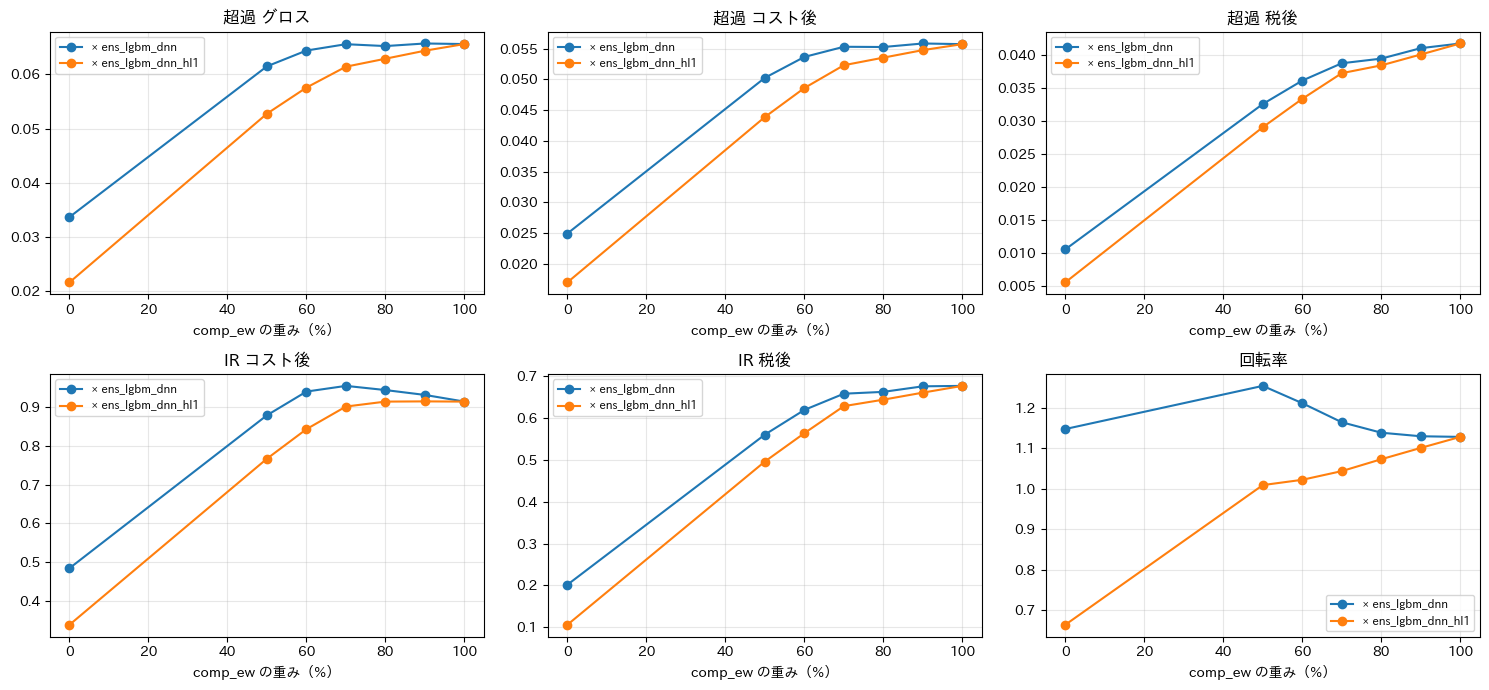

In [5]:
def family(tag):
    return ["comp_ew"] + [f"comp_ew_{w}_{tag}_{100 - w}" for w in W] + [("ens_lgbm_dnn" if tag == "ai" else "ens_lgbm_dnn_hl1")]

xw = [100] + W + [0]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ["超過 グロス", "超過 コスト後", "超過 税後", "IR コスト後", "IR 税後", "回転率"]):
    for tag, label in [("ai", "× ens_lgbm_dnn"), ("ai_hl1", "× ens_lgbm_dnn_hl1")]:
        ax.plot(xw, [tbl.loc[n, col] for n in family(tag)], marker="o", label=label)
    ax.set_xlabel("comp_ew の重み（%）")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. 制約の張り付き

- TE 枠: 推定 TE（omega）が目標 5% にどれだけ近いか（5% 未満なら他の制約が効いて枠を使い切れていない）
- 回転率上限 15%/月: `rot ≥ 14.9%` の月の割合
- 業種 ±3%、個別 ±3% / 上限 10%: 上下限に張り付いた数

In [6]:
rows = {}
for n, out in outs.items():
    obj = out.objective().iloc[1:]
    perf = out.performance().iloc[1:]
    h = results[n].holdings
    ind = results[n].exposures["industry"]
    rows[n] = {
        "omega 平均": obj["omega"].mean(), "omega ≥ 4.9% の月": (obj["omega"] >= 0.049).mean(),
        "回転率 ≥ 14.9% の月": (perf["rot"] >= 0.149).mean(), "回転率 平均/月": perf["rot"].mean(),
        "業種 下限張り付き（平均本数）": (ind["at_lower"] * len(out.rebalance_dates)).sum() / len(out.rebalance_dates), "業種 上限張り付き（平均本数）": (ind["at_upper"] * len(out.rebalance_dates)).sum() / len(out.rebalance_dates),
        "個別 上限張り付き（平均）": h["n_at_upper"].mean(), "個別 下限張り付き（平均）": h["n_at_lower"].mean(),
        "アルファ（opt 加重）": h["alpha_weighted"].mean(), "アルファ（BM 加重）": h["alpha_bm_weighted"].mean(),
    }
display(pd.DataFrame(rows).T.round(3))

,omega 平均,omega ≥ 4.9% の月,回転率 ≥ 14.9% の月,回転率 平均/月,業種 下限張り付き（平均本数）,業種 上限張り付き（平均本数）,個別 上限張り付き（平均）,個別 下限張り付き（平均）,アルファ（opt 加重）,アルファ（BM 加重）
comp_ew,0.049,0.810,0.018,0.094,2.049,1.256,3.939,3.470,1.020,0.046
comp_ew_90_ai_10,0.049,0.804,0.025,0.094,1.982,1.177,3.982,3.512,1.047,0.118
comp_ew_80_ai_20,0.049,0.785,0.025,0.095,1.902,1.073,4.152,3.482,1.075,0.196
comp_ew_70_ai_30,0.049,0.767,0.025,0.097,1.878,1.091,4.256,3.549,1.105,0.283
comp_ew_60_ai_40,0.048,0.736,0.067,0.101,1.854,1.037,4.585,3.543,1.130,0.375
comp_ew_50_ai_50,0.048,0.650,0.153,0.104,1.799,1.189,4.579,3.524,1.154,0.468
ens_lgbm_dnn,0.041,0.123,0.160,0.096,1.317,1.585,4.421,2.518,1.076,0.804
comp_ew_90_ai_hl1_10,0.049,0.810,0.025,0.092,1.982,1.189,4.006,3.567,1.054,0.122
comp_ew_80_ai_hl1_20,0.049,0.791,0.012,0.089,1.884,1.128,4.433,3.518,1.094,0.211
comp_ew_70_ai_hl1_30,0.049,0.779,0.012,0.087,1.841,1.079,4.640,3.537,1.136,0.307


## 6. リスクモデルによる分解（Style / Industry / Country / Specific）

超過リターン（コスト前）と推定リスクの分解。

In [7]:
fl = store.factor_list(RISK_MODEL)
fr = store.factor_return(RISK_MODEL)
rows = {}
for n in HIGHLIGHT + ["ens_lgbm_dnn_hl1", "comp_ew_70_ai_hl1_30"]:
    groups, _ = factor_attribution(outs[n], fr, fl)
    rd = risk_decomposition(outs[n], lambda d: store.factor_covariance(RISK_MODEL, d), fl)
    g = groups.iloc[BURN_IN:]
    rows[n] = {**{f"寄与 {c}": g[c].mean() * 12 for c in ["Style", "Industry", "Country", "specific"]}, "寄与 合計": g["excess_gross"].mean() * 12,
               **{f"リスク分散シェア {c}": rd[f"share_{c}"].mean() for c in ["Style", "Industry", "Country", "specific"]}, "te_factor": rd["te_factor"].mean(), "te_specific": rd["te_specific"].mean()}
display(pd.DataFrame(rows).T.round(4))

,寄与 Style,寄与 Industry,寄与 Country,寄与 specific,寄与 合計,リスク分散シェア Style,リスク分散シェア Industry,リスク分散シェア Country,リスク分散シェア specific,te_factor,te_specific
comp_ew,0.0140,0.0033,0.0015,0.0495,0.0684,0.2696,0.0194,0.0439,0.6671,0.0282,0.0401
comp_ew_70_ai_30,0.0163,0.0035,0.0000,0.0468,0.0667,0.2832,0.0212,0.0302,0.6654,0.0280,0.0396
comp_ew_60_ai_40,0.0170,0.0032,-0.0005,0.0451,0.0648,0.2891,0.0227,0.0312,0.6570,0.0282,0.0391
ens_lgbm_dnn,0.0127,0.0041,-0.0014,0.0186,0.0340,0.2192,0.0371,0.0468,0.6969,0.0224,0.0338
ens_lgbm_dnn_hl1,0.0089,0.0039,-0.0020,0.0104,0.0212,0.2051,0.0354,0.0412,0.7183,0.0214,0.0340
comp_ew_70_ai_hl1_30,0.0161,0.0039,-0.0002,0.0429,0.0627,0.2799,0.0209,0.0281,0.6712,0.0278,0.0398


## 7. 制約なしの Q5 等ウェイトとの比較

同じスコアで Q5（最上位 20%）を等ウェイトで保有した場合（コスト前、USD 建て `rtn_usd`）と、最適化のグロス超過を並べる。
最適化の「実現率」= 最適化グロス超過 ÷ Q5 EW 超過。

In [8]:
start, end = first.rebalance_dates.min(), first.rebalance_dates.max()
univ = store.universe(start, end)
bm_w = store.benchmark(BENCHMARK, start, end)
rtn_usd = store.returns(RISK_MODEL, "rtn_usd", start, None)
bm_ret = portfolio_returns(bm_w, rtn_usd)
score_path = {n: ("composite/comp_ew" if n == "comp_ew" else f"my_ai/{n}" if n.startswith("ens_") else f"composite/{n}") for n in NAMES}
rows = {}
for n in NAMES:
    q = quantile_analysis(store.alpha(score_path[n], start, end), rtn_usd, univ, n_quantiles=5)
    r = q.returns[q.top].iloc[BURN_IN:]
    s = performance_summary(r, bm_ret.reindex(r.index), q.turnover[q.top].reindex(r.index))
    rows[n] = {"Q5 EW 超過（制約なし）": s["active_return"], "Q5 EW TE": s["tracking_error"], "Q5 EW IR": s["information_ratio"], "Q5 EW 回転率": s["turnover_annual"],
               "最適化 グロス超過": tbl.loc[n, "超過 グロス"], "最適化 TE": tbl.loc[n, "TE 実現"], "最適化 IR": tbl.loc[n, "IR コスト後"], "実現率": tbl.loc[n, "超過 グロス"] / s["active_return"]}
cmp = pd.DataFrame(rows).T
display(cmp.round(3))

,Q5 EW 超過（制約なし）,Q5 EW TE,Q5 EW IR,Q5 EW 回転率,最適化 グロス超過,最適化 TE,最適化 IR,実現率
comp_ew,0.131,0.113,1.159,4.046,0.066,0.061,0.915,0.499
comp_ew_90_ai_10,0.131,0.110,1.193,4.089,0.066,0.060,0.932,0.500
comp_ew_80_ai_20,0.130,0.106,1.234,4.158,0.065,0.059,0.945,0.500
comp_ew_70_ai_30,0.134,0.101,1.320,4.218,0.066,0.058,0.956,0.491
comp_ew_60_ai_40,0.134,0.097,1.382,4.388,0.064,0.057,0.941,0.480
comp_ew_50_ai_50,0.133,0.094,1.411,4.537,0.062,0.057,0.880,0.463
ens_lgbm_dnn,0.108,0.085,1.279,5.167,0.034,0.051,0.484,0.311
comp_ew_90_ai_hl1_10,0.131,0.109,1.200,3.948,0.064,0.060,0.916,0.492
comp_ew_80_ai_hl1_20,0.132,0.105,1.256,3.818,0.063,0.059,0.915,0.476
comp_ew_70_ai_hl1_30,0.132,0.100,1.320,3.670,0.061,0.058,0.902,0.467


## 所見

評価期間 2014-01〜2026-07（バーンイン 12 か月後、151 か月）。13 本とも同じ制約（TE ≤ 5%、個別・業種 ±3%、回転率 ≤ 15%/月）。

**基本指標（対 MSCI India、USD 建て。税は INR 建てで計算）**

| | 超過 グロス | 超過 コスト後 | 超過 税後 | TE 実現 | IR コスト後 | IR 税後 | 回転率 | 実現率 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| comp_ew | 6.6% | 5.6% | **4.2%** | 6.1% | 0.92 | **0.68** | 113% | 50% |
| comp_ew_80_ai_20 | 6.5% | 5.5% | 3.9% | 5.9% | 0.95 | 0.66 | 114% | 50% |
| comp_ew_70_ai_30 | 6.6% | 5.5% | 3.9% | 5.8% | **0.96** | 0.66 | 116% | 49% |
| comp_ew_60_ai_40 | 6.4% | 5.4% | 3.6% | 5.7% | 0.94 | 0.62 | 121% | 48% |
| comp_ew_70_ai_hl1_30 | 6.1% | 5.2% | 3.7% | 5.8% | 0.90 | 0.63 | 104% | 47% |
| ens_lgbm_dnn | 3.4% | 2.5% | 1.0% | 5.1% | 0.48 | 0.20 | 115% | 31% |
| ens_lgbm_dnn_hl1 | 2.2% | 1.7% | 0.5% | 5.0% | 0.34 | 0.11 | 66% | 20% |

- **制約下では複合の優位がほぼ消える。** 制約なし Q5 EW では 60:40 が IR 1.38（comp_ew 1.16）だったが、最適化後はグロス超過 6.4〜6.6% で横並び、
  IR は 70:30 の 0.96 が最高でも comp_ew（0.92）との差は 0.04。税後では回転率と短期比率が AI 比率とともに上がる（113% → 125%、短期比率 46% → 52%）ため
  **comp_ew 単体が最良**（4.2%、IR 0.68）。
- 平滑化系統（`_hl1`）は最適化後はすべて生系統より劣る。回転率制約（15%/月）が既に平滑化の役割を果たしており、スコア側の平滑化は情報の遅れにしかならない。
- **AI 単体は制約下で大きく劣後**（グロス 3.4%、実現率 31%）。推定 TE が平均 4.1% と目標 5% に届かず（omega ≥ 4.9% の月が 12%）、
  アクティブシェアも 57%（comp_ew 66%）。TE 枠を使い切れない原因は、AI スコアの **BM 加重平均が +0.80**（comp_ew は +0.05）であること。
  AI スコアは大型株（ベンチマーク構成銘柄）で高く、長期的に見れば「大型を買う」方向の情報が多い。
  ロングオンリーで対 BM ±3%・業種 ±3% の制約下ではこのティルトは実現できず、サイズ中立化された comp_ew に比べてアルファが制約に吸収される。
  回転率上限に当たる月も 16%（comp_ew 2%）と多く、信号の変化が速いことも効いている。
- 実現 TE / 推定 TE は 1.18〜1.26 で全本同程度。固有リスクの過小推定は共通。

**リスク分解（コスト前の超過、年率寄与）**

| | Style | Industry | Specific | 合計 |
| --- | --- | --- | --- | --- |
| comp_ew | 1.4% | 0.3% | 5.0% | 6.8% |
| comp_ew_70_ai_30 | 1.6% | 0.4% | 4.7% | 6.7% |
| ens_lgbm_dnn | 1.3% | 0.4% | 1.9% | 3.4% |

- 複合は Style 寄与がやや増え Specific がやや減る。AI 単体は Specific 寄与が comp_ew の 4 割に留まる。
  制約なしの srtn 評価（`02`）では AI の固有 IR が高かったが、最適化後のポートフォリオにはそれが残らない。

**判断**

1. 現時点で最適化に入れるスコアは **`comp_ew` 単体**。複合（70:30 / 80:20）はコスト後 IR で +0.03〜0.04 の改善に留まり、税後では劣る。
2. AI スコアを最適化で活かすには、**サイズ（と業種）中立化**が先。`comp_ew` と同じ処理（Blom → GICS セクターダミー + log 時価総額への回帰残差）を
   AI スコアに施してから複合すれば、制約に吸収される部分が減る見込み。india-ai-model 側で特徴量にサイズを入れているなら、学習目的自体をサイズ中立に
   する選択肢もある。
3. 制約側では、AI の情報を使うなら回転率上限（15%/月）がボトルネック。ただし税コストの観点からは緩和したくないので、スコア側で対応する方が筋が良い。

**次のステップ候補**

- AI スコアのサイズ・業種中立化版（`ens_lgbm_dnn_neu`）を作り、制約なし（`02` の枠組み）と最適化（本 Notebook）の両方で再評価する
- 最適化の制約感応度: 回転率上限 20% / 対 BM ±4% で AI 単体・複合がどこまで回復するかを 1〜2 本だけ試す